In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import mapclassify
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.lines import Line2D

In [2]:
name_territory = "Verdon_carte"
name_background = "Verdon"

In [3]:
grid= gpd.read_file(f"data_output/final_result/{name_territory}.shp")
background= gpd.read_file(f"data_output/final_result/{name_background}.shp")

grid["photo"]= grid["leasure"]+grid["nature"]
print(grid.columns)

Index(['square_id', 'sq_id_2X', 'nb_autumn', 'nb_spring', 'nb_summer',
       'nb_winter', 'nat_autumn', 'nat_spring', 'nat_summer', 'nat_winter',
       'nature', 'leas_autum', 'leas_sprin', 'leas_sumer', 'leas_wint',
       'leasure', 'dist_path', 'dist_road', 'dist_town', 'area_cell', 'Ffer_C',
       'Ffer_F', 'Ffer_M', 'Ffer_sansA', 'Fouv_C', 'Fouv_F', 'Fouv_M',
       'Fouv_sansA', 'Peupleraie', 'vege_bas', 'sans_foret', 'FFC_10km',
       'FFF_10km', 'FFM_10km', 'FFA_10km', 'FOC_10km', 'FOF_10km', 'FOM_10km',
       'FOA_10km', 'Peup10km', 'grass10km', 'elevation', 'veg_alt', 'veg_q10',
       'veg_q90', 'veg_sd', 'apl_bird', 'apl_bird_c', 'apl', 'apl_square',
       'CvF', 'hauteur', 'access', 'ouverture', 'mixite', 'geometry', 'photo'],
      dtype='object')


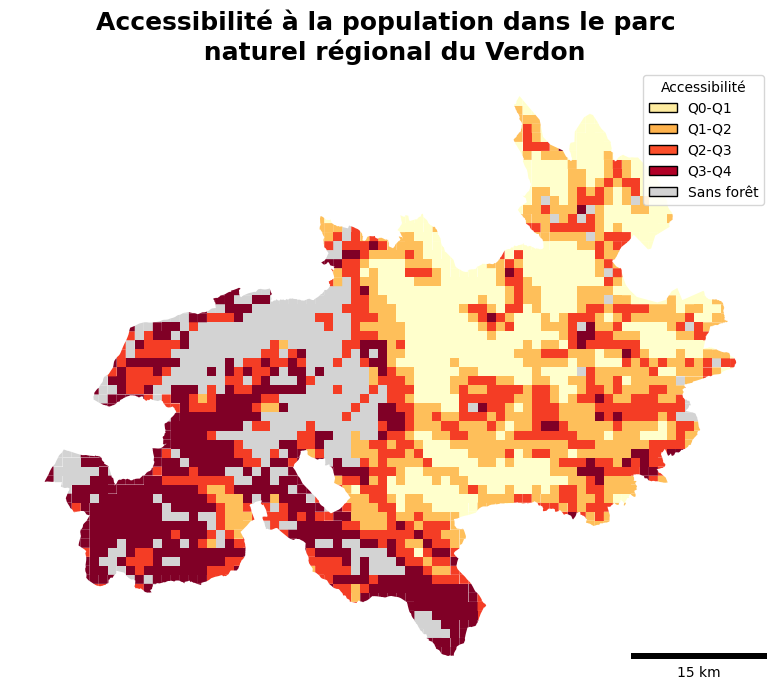

In [4]:
fig, ax = plt.subplots(figsize=(10, 8))

grid_sans_foret = background[background["sans_foret"]>50]
grid_sans_foret.plot(ax=ax,color="lightgrey",legend=False)
grid.plot(ax =ax,column="access", cmap="YlOrRd", scheme="Quantiles",k=4,legend=True)


ax.set_title("Accessibilité à la population dans le parc \n naturel régional du Verdon", fontsize=18, fontweight="bold")
plt.axis("off")
#ax.set_axis_off()

legend_elements = [
    Patch(facecolor="#feeca0", edgecolor="black", label="Q0-Q1"),
    Patch(facecolor="#feb24c", edgecolor="black", label="Q1-Q2"),
    Patch(facecolor="#fc4e2a", edgecolor="black", label="Q2-Q3"),
    Patch(facecolor="#b10026", edgecolor="black", label="Q3-Q4"),
    Patch(facecolor="lightgrey", edgecolor="black", label="Sans forêt")
]
scalebar = ScaleBar(1, units="m", location="lower right")
ax.add_artist(scalebar)
ax.legend(handles=legend_elements, title="Accessibilité")
plt.show()

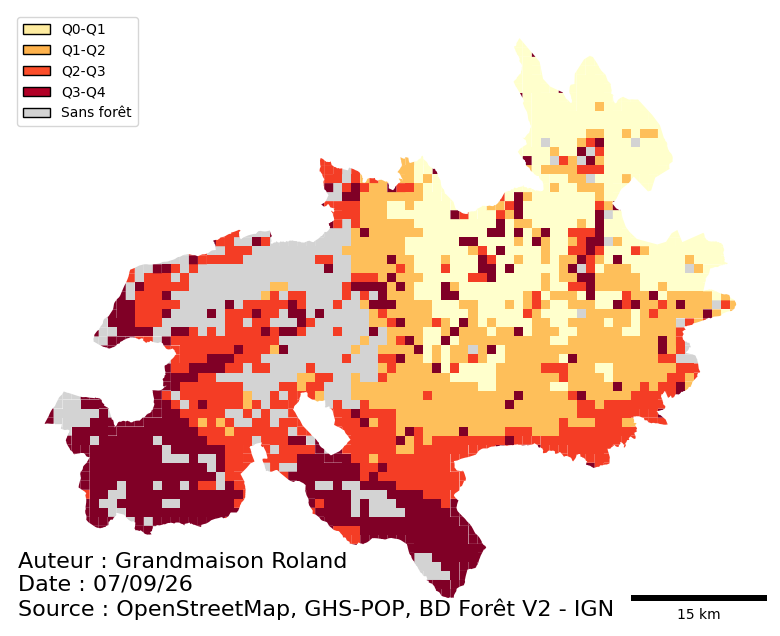

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
grid_sans_foret = background[background["sans_foret"] > 50]
grid_sans_foret.plot(ax=ax,color="lightgrey",legend=False)

grid.plot(ax=ax,column="apl_square",cmap="YlOrRd",scheme="quantiles",k=4,legend=True)


plt.axis("off")
#ax.set_axis_off()
ax.text(
    0.01, 0.01,
    "Auteur : Grandmaison Roland\nDate : 07/09/26\nSource : OpenStreetMap, GHS-POP, BD Forêt V2 - IGN",
    transform=ax.transAxes,
    fontsize=16,
    verticalalignment="bottom",
    horizontalalignment="left"
)
legend_elements = [
    Patch(facecolor="#feeca0", edgecolor="black", label="Q0-Q1"),
    Patch(facecolor="#feb24c", edgecolor="black", label="Q1-Q2"),
    Patch(facecolor="#fc4e2a", edgecolor="black", label="Q2-Q3"),
    Patch(facecolor="#b10026", edgecolor="black", label="Q3-Q4"),
    Patch(facecolor="lightgrey", edgecolor="black", label="Sans forêt")
]
scalebar = ScaleBar(1, units="m", location="lower right")
ax.add_artist(scalebar)
ax.legend(handles=legend_elements,loc = "upper left",)
plt.show()

/local/AIX/rgrandmaiso/.local/lib/python3.10/site-packages/geopandas/plotting.py:746: UserWarning: Numba not installed. Using slow pure python version.
  binning = mapclassify.classify(


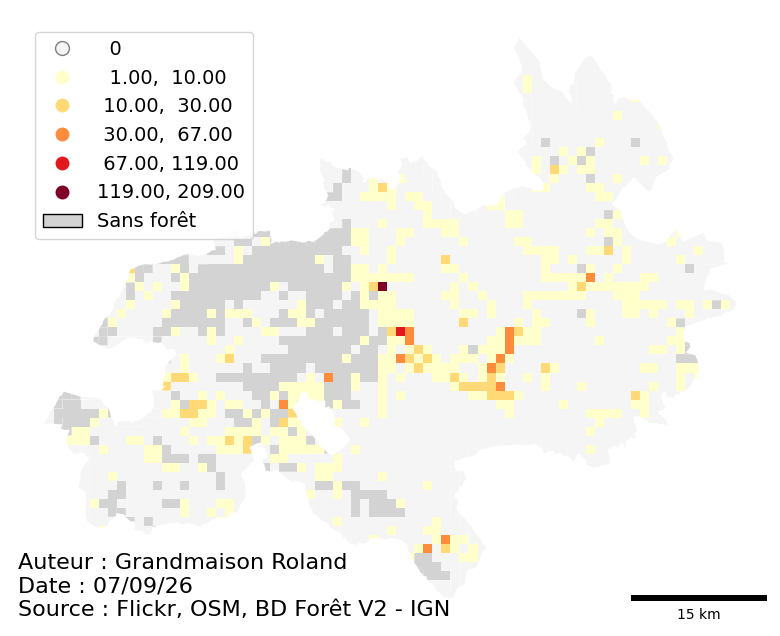

In [17]:
fig, ax = plt.subplots(figsize=(10, 8))
grid_sans_foret = background[background["sans_foret"] > 50]
grid_sans_foret.plot(ax=ax,color="lightgrey",legend=False)

grid_zero = grid[grid["photo"] == 0]
grid_positive = grid[grid["photo"] > 0]

# Afficher les valeurs = 0
grid_zero.plot(ax=ax,color="whitesmoke",linewidth=0.5)

# Afficher les valeurs > 0 avec Fisher-Jenks
grid_positive.plot(ax=ax, column="photo",cmap="YlOrRd",scheme="fisherjenks",k=5,legend=True)

#grid.plot(ax=ax,column="photo",cmap="YlOrRd",scheme="fisherjenks",k=5,legend=True)
legend = ax.get_legend()
#ax.set_title("Répartition des interactions homme-nature \n dans la parc naturel régional du Verdon", fontsize=18, fontweight="bold")

ax.text(
    0.01, 0.01,
    "Auteur : Grandmaison Roland\nDate : 07/09/26\nSource : Flickr, OSM, BD Forêt V2 - IGN",
    transform=ax.transAxes,
    fontsize=16,
    verticalalignment="bottom",
    horizontalalignment="left"
)

handles = legend.legend_handles
labels = [text.get_text() for text in legend.get_texts()]

#handles.insert(0,Patch(facecolor="whitesmoke", edgecolor="black", label="0"))
handles.insert(0,Line2D([0], [0],marker='o',color='grey',markerfacecolor='whitesmoke',markersize=10,linestyle='None',label='0'))
labels.insert(0, "  0")

handles.append(Patch(facecolor="lightgrey",edgecolor="black",label="Sans forêt"))
labels.append("Sans forêt")
ax.legend(handles=handles,labels=labels,loc="upper left",bbox_to_anchor=(0.02, 0.98),fontsize=14,title_fontsize=16)

# Recréer la légende
#ax.legend(handles=handles,labels=labels,loc="upper left",bbox_to_anchor=(0, 1))

plt.axis("off")

scalebar = ScaleBar(1,units="m",location="lower right")

ax.add_artist(scalebar)
plt.show()

/local/AIX/rgrandmaiso/.local/lib/python3.10/site-packages/geopandas/plotting.py:746: UserWarning: Numba not installed. Using slow pure python version.
  binning = mapclassify.classify(


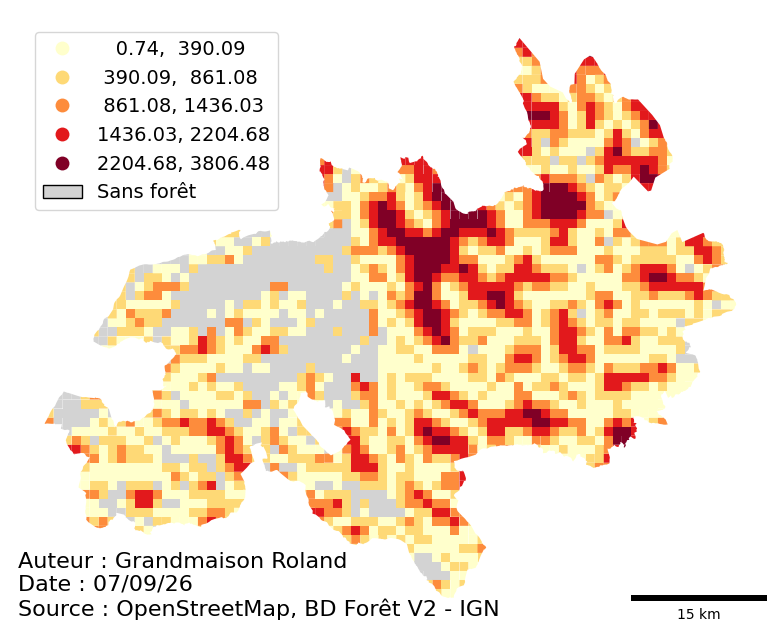

In [21]:
fig, ax = plt.subplots(figsize=(10, 8))
grid_sans_foret = background[background["sans_foret"] > 50]
grid_sans_foret.plot(ax=ax,color="lightgrey",legend=False)


grid.plot(ax=ax,column="dist_road",cmap="YlOrRd",scheme="fisherjenks",k=5,legend=True)


#grid.plot(ax=ax,column="photo",cmap="YlOrRd",scheme="fisherjenks",k=5,legend=True)
legend = ax.get_legend()
#ax.set_title("Répartition des interactions homme-nature \n dans la parc naturel régional du Verdon", fontsize=18, fontweight="bold")
ax.text(
    0.01, 0.01,
    "Auteur : Grandmaison Roland\nDate : 07/09/26\nSource : OpenStreetMap, BD Forêt V2 - IGN",
    transform=ax.transAxes,
    fontsize=16,
    verticalalignment="bottom",
    horizontalalignment="left"
)

handles = legend.legend_handles
labels = [text.get_text() for text in legend.get_texts()]

handles.append(Patch(facecolor="lightgrey",edgecolor="black",label="Sans forêt"))
labels.append("Sans forêt")
ax.legend(handles=handles,labels=labels,loc="upper left",bbox_to_anchor=(0.02, 0.98),fontsize=14,title_fontsize=16)

# Recréer la légende
#ax.legend(handles=handles,labels=labels,loc="upper left",bbox_to_anchor=(0, 1))

plt.axis("off")

scalebar = ScaleBar(1,units="m",location="lower right")

ax.add_artist(scalebar)
plt.show()

/local/AIX/rgrandmaiso/.local/lib/python3.10/site-packages/geopandas/plotting.py:746: UserWarning: Numba not installed. Using slow pure python version.
  binning = mapclassify.classify(


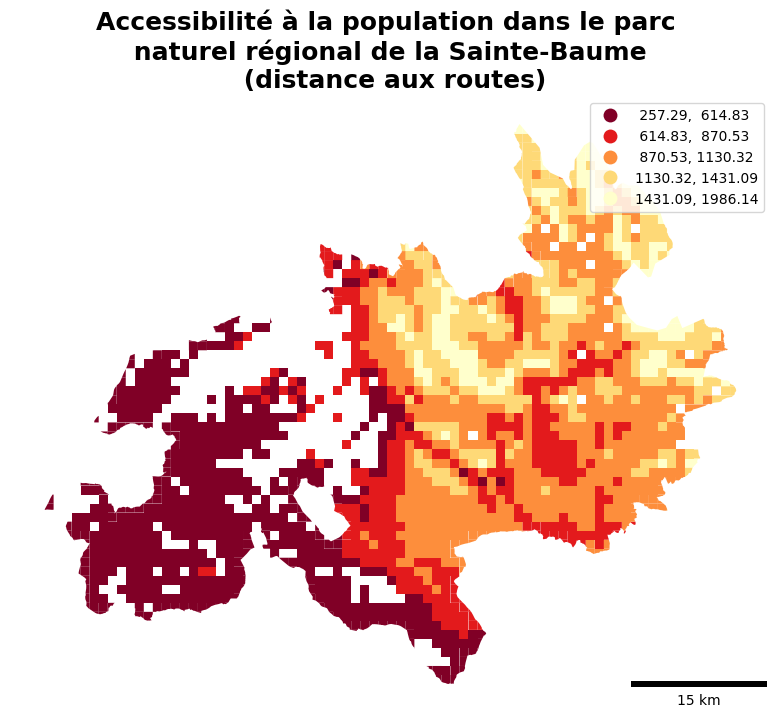

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
grid.plot(ax =ax,column="elevation", cmap="YlOrRd_r", scheme="fisherjenks",k=5,legend=True)
ax.set_title("Accessibilité à la population dans le parc \n naturel régional de la Sainte-Baume \n (distance aux routes)", fontsize=18, fontweight="bold")
plt.axis("off")
scalebar = ScaleBar(1, units="m", location="lower right")
ax.add_artist(scalebar)
plt.show()

/local/AIX/rgrandmaiso/.local/lib/python3.10/site-packages/geopandas/plotting.py:746: UserWarning: Numba not installed. Using slow pure python version.
  binning = mapclassify.classify(


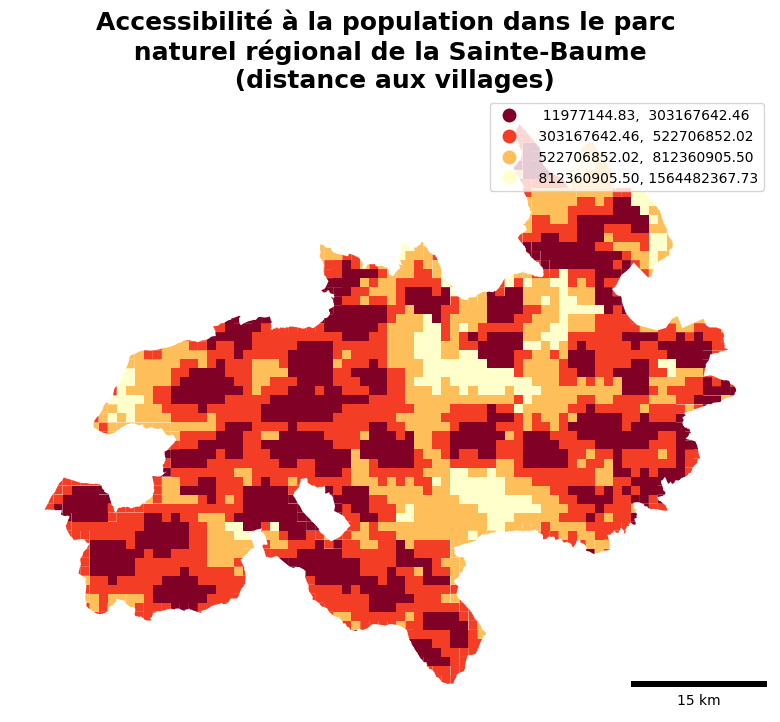

In [159]:
fig, ax = plt.subplots(figsize=(10, 8))
grid.plot(ax =ax,column="dist_town", cmap="YlOrRd_r", scheme="fisherjenks",k=4,legend=True)
ax.set_title("Accessibilité à la population dans le parc \n naturel régional de la Sainte-Baume \n (distance aux villages)", fontsize=18, fontweight="bold")
plt.axis("off")
scalebar = ScaleBar(1, units="m", location="lower right")
ax.add_artist(scalebar)
plt.show()

In [160]:
print(grid["nature"].value_counts().sort_index())
#print(grid["leasure"].value_counts().sort_index())

nature
0.0      1798
1.0       270
2.0        91
3.0        44
4.0        38
5.0        25
6.0        14
7.0        18
8.0         6
9.0         9
10.0        7
11.0        7
12.0        8
13.0        3
14.0        5
15.0        3
16.0        3
17.0        6
18.0        8
19.0        2
20.0        6
21.0        2
22.0        4
23.0        2
24.0        3
25.0        1
27.0        3
28.0        1
29.0        1
30.0        1
32.0        1
33.0        1
34.0        1
36.0        2
38.0        1
40.0        1
42.0        1
43.0        1
44.0        1
46.0        1
47.0        1
50.0        1
51.0        2
64.0        1
93.0        1
166.0       1
Name: count, dtype: int64


In [3]:
import pandas as pd
import mapclassify

grid["nature_cl"] = 0

grid.loc[(grid["nature"] > 0) & (grid["nature"] < 10), "nature_cl"] = 1
grid.loc[grid["nature"] >= 5, "nature_cl"] = 2

grid["leasure_cl"] = 0

grid.loc[(grid["leasure"] > 0) & (grid["leasure"] < 10), "leasure_cl"] = 1
grid.loc[grid["leasure"] >= 5, "leasure_cl"] = 2

# ------------------------------------------------------
# Classe bivariée
# ------------------------------------------------------

grid["classe"] = (
    grid["nature_cl"].astype(str)
    + "-"
    + grid["leasure_cl"].astype(str)
)

# ------------------------------------------------------
# Vérification
# ------------------------------------------------------

print("Nature")
print(grid["nature_cl"].value_counts().sort_index())

print("\nLeasure")
print(grid["leasure_cl"].value_counts().sort_index())

print("\nClasses bivariées")
print(grid["classe"].value_counts().sort_index())

Nature
nature_cl
0    1798
1     443
2     166
Name: count, dtype: int64

Leasure
leasure_cl
0    2161
1     220
2      26
Name: count, dtype: int64

Classes bivariées
classe
0-0    1742
0-1      56
1-0     366
1-1      74
1-2       3
2-0      53
2-1      90
2-2      23
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np

# Palette (adapter si besoin)
palette = {

    "0-0":"#e8e8e8",
    "1-0":"#b5c0da",
    "2-0":"#6c83b5",

    "0-1":"#b8d6be",
    "1-1":"#90b2b3",
    "2-1":"#567994",

    "0-2":"#73ae80",
    "1-2":"#5a9178",
    "2-2":"#2a5a5b"

}

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.transforms import Affine2D


def draw_bivariate_legend(ax, palette,
                          xlabel="Nature",
                          ylabel="Loisirs",
                          low="Faible",
                          high="Fort"):

    # --------------------------------------------------
    # Préparation
    # --------------------------------------------------

    ax.set_xlim(-2.5, 5)
    ax.set_ylim(-2.5, 5)
    ax.set_aspect("equal")
    ax.axis("off")

    # Rotation de la grille
    trans = Affine2D().rotate_deg_around(1.5, 1.5, 45) + ax.transData

    # Ordre des couleurs
    #
    #        Leisure ↑
    #
    # 0-2 1-2 2-2
    # 0-1 1-1 2-1
    # 0-0 1-0 2-0
    #
    colors = [
        ["0-2", "1-2", "2-2"],
        ["0-1", "1-1", "2-1"],
        ["0-0", "1-0", "2-0"]
    ]

    # --------------------------------------------------
    # Dessin des 9 carrés
    # --------------------------------------------------

    for j in range(3):
        for i in range(3):

            rect = Rectangle(
                (i, 2-j),
                1,
                1,
                facecolor=palette[colors[j][i]],
                edgecolor="white",
                linewidth=1.2,
                transform=trans,
            )

            ax.add_patch(rect)

   
   
    # --------------------------------------------------
    # Axes
    # --------------------------------------------------

    # Axe droite
    ax.annotate(
        "",
        xy=(4,1.5),
        xytext=(1.5,-1),
        arrowprops=dict(arrowstyle="-|>", lw=1.4)
    )

    # Axe gauche
    ax.annotate(
        "",
        xy=(-1,1.5),
        xytext=(1.5,-1),
        arrowprops=dict(arrowstyle="-|>", lw=1.4)
    )

    # Titres

    ax.text(
        -0.5,
        -1.1,
        ylabel,
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

    ax.text(
        3.6,
        -1.1,
        xlabel,
        ha="center",
        fontsize=12,
        fontweight="bold"
    )
    for x, valeur in zip([2.5, 3.3], [0, 5]):
        ax.text(
            x,
            -3 + (x+0.6)  * 0.8,
            str(valeur),
            ha="center",
            fontsize=9
        )

    for x, valeur in zip([0.5, -0.3], [0, 5]):
        ax.text(
            x,
            -1.5 + (1.5 - x) * 0.9,
            str(valeur),
            ha="center",
            fontsize=9
        )
    

   

    
    

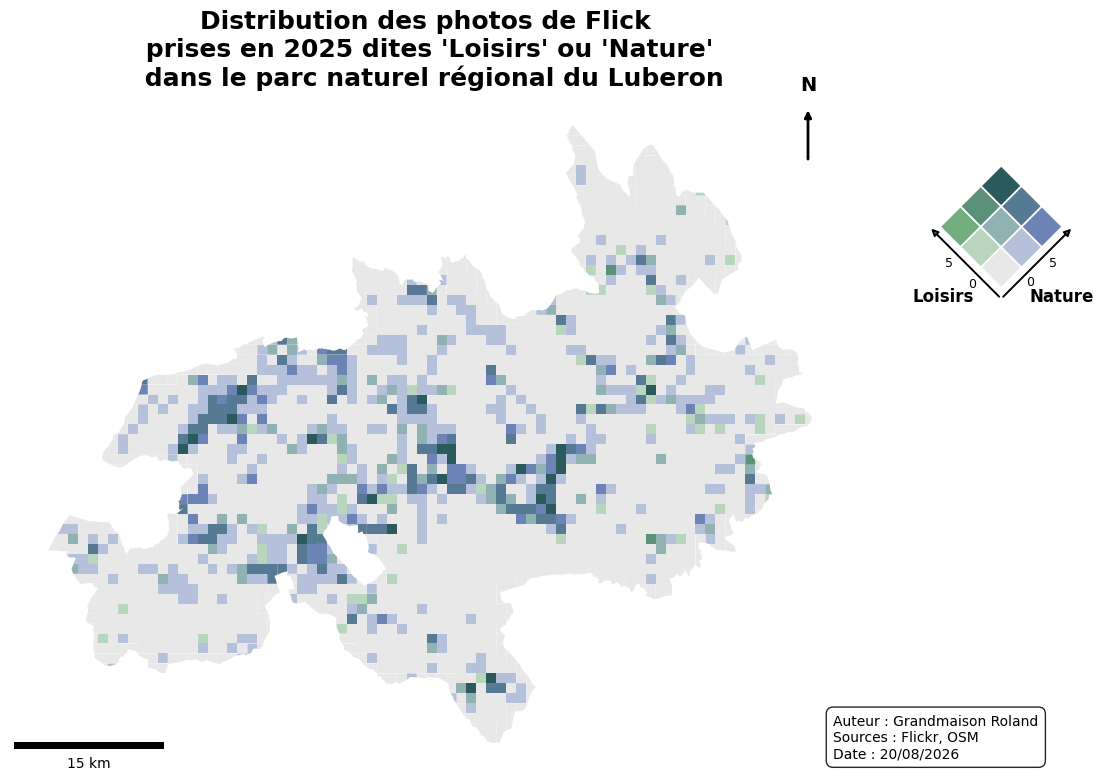

In [ ]:
fig = plt.figure(figsize=(12,10))
from datetime import datetime

date_creation = datetime.now().strftime("%d/%m/%Y")
# Carte
ax_map = fig.add_axes([0.05,0.05,0.70,0.90])


grid.plot(
    color=grid["classe"].map(palette),
    linewidth=0,
    ax=ax_map
)
ax_map.set_title("Distribution des photos de Flick \n prises en 2025 dites 'Loisirs' ou 'Nature' \n dans le parc naturel régional du Luberon", fontsize=18, fontweight="bold")
scalebar = ScaleBar(1, units="m", location="lower left")
ax_map.add_artist(scalebar)

info = (
    "Auteur : Grandmaison Roland\n"
    "Sources : Flickr, OSM\n"
    f"Date : {date_creation}"
)
ax_map.text(0.98, 0.02,info,transform=ax_map.transAxes,fontsize=10,ha="left",va="bottom",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="black",
        alpha=0.85
    )
)
ax_map.annotate(
    "",
    xy=(0.95, 0.98),
    xytext=(0.95, 0.90),
    xycoords="axes fraction",
    arrowprops=dict(
        arrowstyle="-|>",
        lw=2,
        color="black"
    )
)

ax_map.text(
    0.95,
    1,
    "N",
    transform=ax_map.transAxes,
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold"
)

ax_map.axis("off")

# Légende
ax_leg = fig.add_axes([0.78,0.55,0.18,0.30])


draw_bivariate_legend(ax_leg, palette)

plt.show()
#en ouverture